# Spam Email Detection Using Naive Bayes Classifier
First need to know what we have to work with so we analyze the files we are given.

In [100]:
!ls

 auto_commit.sh   README.ipynb	 report.tex
 code.ipynb	  README.md	 requirements.txt
 emails.csv	  report.pdf	'SPAM Email Dataset.zip'


In [101]:
# !pip freeze
# !unzip SPAM\ Email\ Dataset.zip 

## Counting lines to see how many we have to work with 

In [102]:
!wc -l emails.csv

5729 emails.csv


## Now we explore the data so we can get any features that can connect to spams
so we take the data into a dataframe and see how it goes.

In [103]:
import pandas as pd

df = pd.read_csv('emails.csv')
df

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
...,...,...
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0


So we have a large amount of text blobs with spaces, punctuation marks and other. so lets see how many spam and not spam we have in the dataset
### Spam or not distribution

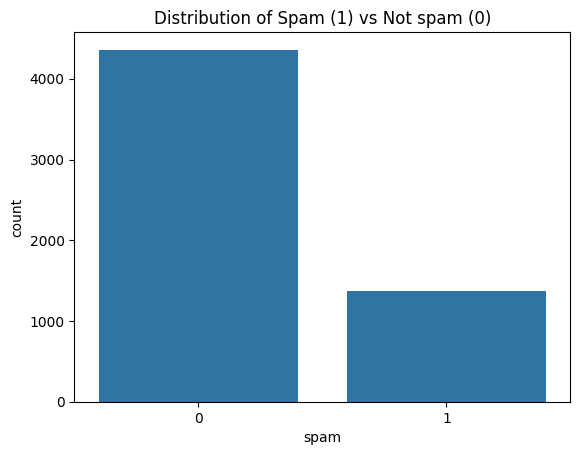

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# plt.figure(figsize=(6, 4))
sns.countplot(x='spam', data=df)
plt.title('Distribution of Spam (1) vs Not spam (0)')
plt.show()


This graph prooves that the dataset is not properly split, or properly balanced between Spam and not spam.
### Now we need see some of the common words

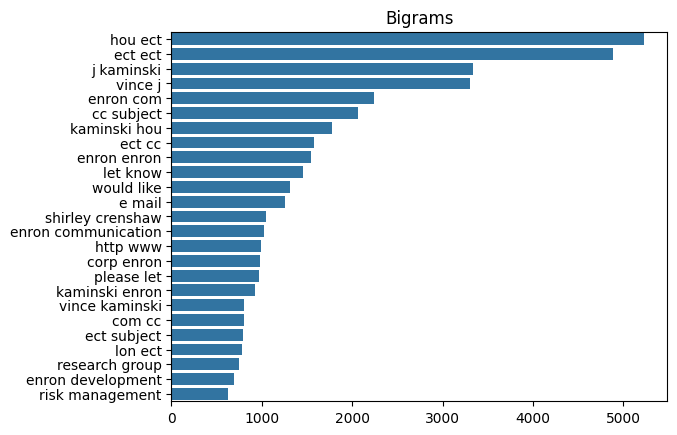

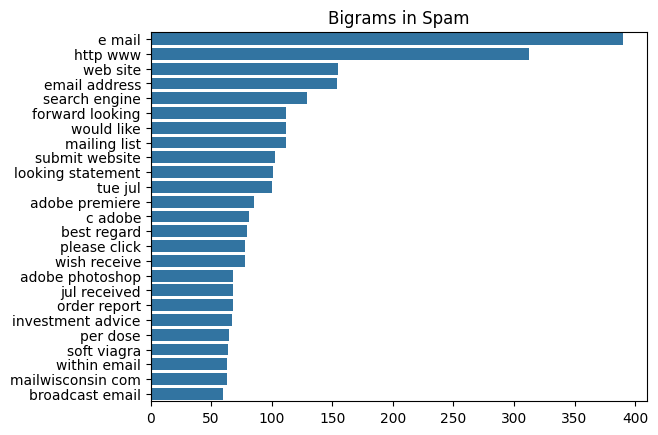

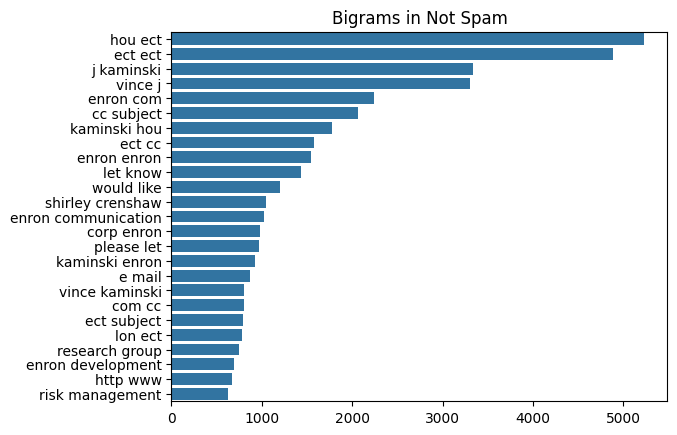

In [ ]:
import matplotlib.pyplot as plt
import re

def draw_ngram(only_the_data, TITLE):
    string_data = ' '.join(only_the_data)

    words = re.findall(r'\b\w+\b', string_data.lower())
    print(words)

    top_bigrams = get_top_ngrams(only_the_data)
    x, y = map(list, zip(*top_bigrams))
    sns.barplot(x=y, y=x)
    plt.title(TITLE)
    plt.show()

draw_ngram(df['text'], "Ngrams")
draw_ngram(df[df['spam']==1]['text'], "Ngrams in Spam")
draw_ngram(df[df['spam']==0]['text'], "Ngrams in Not Spam")

The graph also gives nothing aside from the fact the word subject, symbols etc are too common but they can or cannot have some properties that are connected to the classification feature.
### Lemmatize - (get rid of excess words types)

In [106]:
# Copied from the internet

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK datasets (run these once)
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_spam(text):
    # 2. Clean: Remove non-letters & lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    
    # 3. Tokenize: Split into words
    words = text.split()
    
    # 4. Lemmatize & Remove Stopwords
    # Converts 'winning' -> 'win', 'prizes' -> 'prize'
    clean_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(clean_words)

# Example output:
# "Congratulations! You are winning a free prize!" 
# -> "congratulation win free prize"

[nltk_data] Downloading package stopwords to /home/sadman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/sadman/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [107]:
data = []
l = len(df)
spam = 0
not_spam = 0

for i in range(0, l):
    mp = {}
    mp["text"]  = preprocess_spam(df["text"][i])
    mp["spam"]  = df["spam"][i]
    mp["words"] = mp["text"].split()
    mp["len"]   = len(df["text"][i])
    mp["wc"] = len(mp["words"])
    data.append(mp)
    spam += mp["spam"]
not_spam = l - spam
print(f"Emails    : {l}")
print(f"Spam      : {spam}")
print(f"Not pam   : {not_spam}")

df = pd.DataFrame(data)

Emails    : 5728
Spam      : 1368
Not pam   : 4360


Now that lemmatization is completed lets find out if that is 
### 

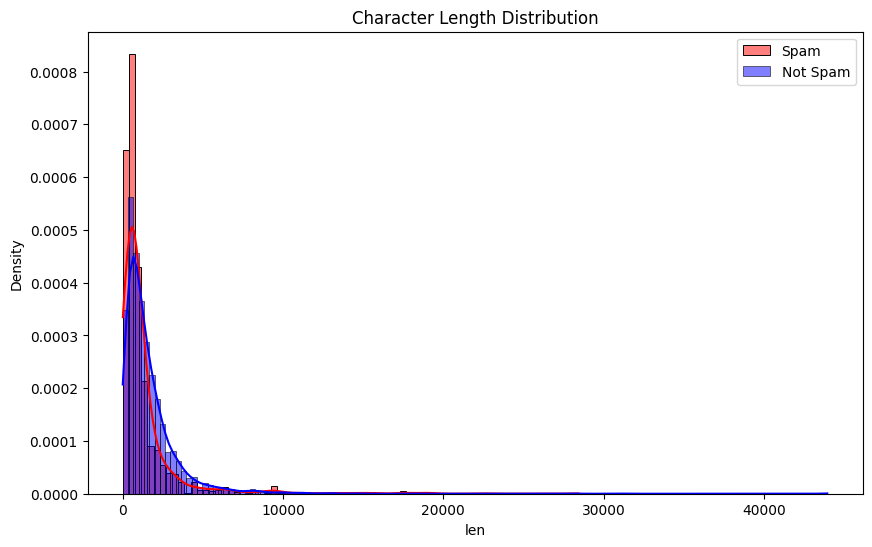

In [108]:
plt.figure(figsize=(10, 6))

# Plotting Spam lengths
sns.histplot(df[df['spam'] == 1]['len'], color='red', label='Spam', kde=True, stat="density")
# Plotting Not Spam lengths
sns.histplot(df[df['spam'] == 0]['len'], color='blue', label='Not Spam', kde=True, stat="density")

plt.title('Character Length Distribution')
plt.legend()
plt.show()

# data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAkQAAAHHCAYAAABeLEexAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAPYQAAD2EBqD+naQAANctJREFUeJzt3XlcVmX+//H3DcqieKMiiyTh1qgkYmFjTGYuJBlaTe6ZuZVToY7S1xwbR9MWncw908rKUivNaVNGlDC1SbTCXKrRscJkMkBTQElA4fz+aLh/3oIbAjd4vZ6Px/14eK5z3df5nMP29pzrnNtmWZYlAAAAg7m5ugAAAABXIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEMEoTz75pGw2W5Vsq0uXLurSpYtjefPmzbLZbFqzZk2VbH/YsGFq2rRplWyrvE6ePKkHH3xQQUFBstlsGjdunKtLqnKrV69Ww4YNdfLkyct+b2Jionx8fHTkyJFKqMwcjz76qG6//fZyvXfgwIHq379/BVcEVyAQocZatmyZbDab4+Xl5aXg4GDFxMRowYIFOnHiRIVs5/Dhw3ryySe1a9euChmvIlXn2i7Fs88+q2XLlumRRx7R8uXLNWTIkPP2LSws1Pz583XDDTfIbrerfv36uv766zVq1Cjt27evCquuOEVFRZo6darGjBkjHx8fR/vGjRs1cuRItW3bVu7u7ucNtnfccYdatmypGTNmVFHFFzZs2DCn/TiXzWbT6NGjq7Cii0tLS9PSpUv1xBNPlFr36quvqk2bNvLy8tJ1112nhQsXluozceJE/eMf/9Du3burolxUJguooV5//XVLkjV9+nRr+fLl1muvvWY9++yzVo8ePSybzWaFhoZau3fvdnrP6dOnrVOnTl3Wdr744gtLkvX6669f1vsKCgqsgoICx/Inn3xiSbLefffdyxqnvLUVFhZa+fn5FbatytCxY0frlltuuaS+vXr1stzd3a3777/fWrRokTVv3jzr4Ycftpo0aXLZX5vq4v3337dsNpv13//+16l96NChlpeXl/WHP/zBatKkiRUaGnreMV588UWrTp06Vm5ubiVXe3FDhw616tate971kqy4uLgqrOji/vznP1u/+93vSrUvWbLEkmT16dPHevnll60hQ4ZYkqyZM2eW6vv73//eGjJkSFWUi0pEIEKNVRKIvvjii1LrkpOTLW9vbys0NNT69ddfr2g7lxuI8vLyymyv6kBUEzRr1syKjY29aL/PP//ckmQ988wzpdadOXPGOnr0aGWUV+nuuusuq1OnTqXaf/rpJ6uwsNCyLMuKjY29YCDKzMy03N3drVdffbWyyrxkNS0QFRYWWo0aNbImT57s1P7rr79afn5+pb43Bw8ebNWtW9c6duyYU/vzzz9v1a1b1zpx4kSl14zKwyUzXJW6deumv/3tb/rxxx+1YsUKR3tZc4iSkpLUqVMn1a9fXz4+PmrVqpXj9PnmzZt10003SZKGDx/uuDy3bNkySb/NE2rbtq1SU1PVuXNn1alTx/Hec+cQlSgqKtITTzyhoKAg1a1bV3fddZfS09Od+jRt2lTDhg0r9d6zx7xYbWXNIcrLy9Njjz2mkJAQeXp6qlWrVnr++edlWZZTv5JLGx988IHatm0rT09PXX/99UpMTCz7gJ8jKytLI0eOVGBgoLy8vBQREaE33njDsb5kPlVaWpoSEhIctR88eLDM8b7//ntJ0i233FJqnbu7u/z8/BzLJV/jffv2qX///rLb7fLz89Of//xn5efnO7339ddfV7du3RQQECBPT0+FhYVp8eLFpbbRtGlT9erVS5s3b1aHDh3k7e2t8PBwbd68WZL03nvvKTw8XF5eXoqMjNRXX3110WOUn5+vxMRERUdHl1oXHBys2rVrX3QMSQoICFC7du304YcfXrDf888/L5vNph9//LHUukmTJsnDw0PHjx+XJB04cEB9+vRRUFCQvLy81KRJEw0cOFA5OTmXVNOlKiws1JQpUxQZGSlfX1/VrVtXt956qz755BOnfgcPHpTNZtPzzz+vRYsWqXnz5qpTp4569Oih9PR0WZalp556Sk2aNJG3t7fuvvtuHTt27KLb/9e//qWjR4+W+hp88skn+uWXX/Too486tcfFxSkvL08JCQlO7bfffrvy8vKUlJRUziOB6oBAhKtWyXyUjRs3nrfPN998o169eqmgoEDTp0/X7Nmzddddd+mzzz6TJLVp00bTp0+XJI0aNUrLly/X8uXL1blzZ8cYv/zyi3r27Kn27dtr3rx56tq16wXreuaZZ5SQkKCJEydq7NixSkpKUnR0tE6dOnVZ+3cptZ3Nsizdddddmjt3ru644w7NmTNHrVq10oQJExQfH1+q/7/+9S89+uijGjhwoJ577jnl5+erT58++uWXXy5Y16lTp9SlSxctX75cgwcP1qxZs+Tr66thw4Zp/vz5jtqXL1+uRo0aqX379o7a/f39yxwzNDRUkrRy5UqdOXPmko5P//79lZ+frxkzZujOO+/UggULNGrUKKc+ixcvVmhoqJ544gnNnj1bISEhevTRR7Vo0aJS43333Xe677771Lt3b82YMUPHjx9X7969tXLlSo0fP17333+/pk2bpu+//179+/dXcXHxBetLTU1VYWGhbrzxxkvanwuJjIzUtm3bLtinf//+stlsWr16dal1q1evVo8ePdSgQQMVFhYqJiZG27dv15gxY7Ro0SKNGjVKP/zwg7Kzsy+pnqNHj5b5Oldubq6WLl2qLl266O9//7uefPJJHTlyRDExMWXOi1u5cqVefPFFjRkzRo899pi2bNmi/v37a/LkyUpMTNTEiRM1atQorV27Vv/3f/930Tq3bdsmm82mG264wam9JNB26NDBqT0yMlJubm6lAm9YWJi8vb0dvzdQQ7n4DBVQbhe6ZFbC19fXuuGGGxzLU6dOtc7+tp87d64lyTpy5Mh5x7jQZanbbrvNkmQtWbKkzHW33XabY7nkktk111zjNN9j9erVliRr/vz5jrbQ0FBr6NChFx3zQrUNHTrU6VLLBx98YEmynn76aad+ffv2tWw2m/Xdd9852iRZHh4eTm27d++2JFkLFy4sta2zzZs3z5JkrVixwtFWWFhoRUVFWT4+Pk77HhoaekmXzIqLix3HOjAw0Bo0aJC1aNEi68cffyzVt+RrfNdddzm1P/roo5Ykp3llZV1OjYmJsZo3b+7UFhoaakmytm3b5mjbsGGDJcny9vZ2quOll16yJFmffPLJBfdp6dKlliRr7969F+x3sUtmlmVZzz77rCXJyszMvGC/qKgoKzIy0qmt5HLkm2++aVmWZX311VflvrQ7dOhQS9IFX2dfMjtz5ozTPDvLsqzjx49bgYGB1ogRIxxtaWlpliTL39/fys7OdrRPmjTJkmRFRERYp0+fdrQPGjTI8vDwuOgcuvvvv9/y8/Mr1R4XF2e5u7uX+R5/f39r4MCBpdp/97vfWT179rzg9lC9cYYIVzUfH58L3m1Wv359SdKHH3540f/Rn4+np6eGDx9+yf0feOAB1atXz7Hct29fNW7cWP/85z/Ltf1L9c9//lPu7u4aO3asU/tjjz0my7K0fv16p/bo6Gi1aNHCsdyuXTvZ7Xb98MMPF91OUFCQBg0a5GirXbu2xo4dq5MnT2rLli2XXbvNZtOGDRv09NNPq0GDBnr77bcVFxen0NBQDRgwoMwzF3FxcU7LY8aMcdRXwtvb2/HvnJwcHT16VLfddpt++OGHUpeHwsLCFBUV5Vju2LGjpN8uz1577bWl2i92nErOtDVo0OCC/S5FyRhlnYU524ABA5Samuq4BClJq1atkqenp+6++25Jkq+vryRpw4YN+vXXXy+7Fi8vLyUlJZX5Ope7u7s8PDwkScXFxTp27JjOnDmjDh06aOfOnaX69+vXz1Gf9P+P9f33369atWo5tRcWFuqnn366YK2//PJLmcf/1KlTjrrK2r+yzuY2aNDgoscf1RuBCFe1kydPOoWPcw0YMEC33HKLHnzwQQUGBmrgwIFavXr1ZYWja6655ry/PMty3XXXOS3bbDa1bNnyvPNnKsqPP/6o4ODgUsejTZs2jvVnO/uPfIkGDRo45plcaDvXXXed3Nycf72cbzuXytPTU3/961/173//W4cPH9bbb7+tm2++WatXry7zVu5zj3OLFi3k5ubmdJw/++wzRUdHq27duqpfv778/f0dc8DODUTnHo+SP8whISFltl/sOJWwzpm/VR4lY1zsGVv9+vWTm5ubVq1a5Xjfu+++q549e8put0uSmjVrpvj4eC1dulSNGjVSTEyMFi1adMnzh9zd3RUdHV3mqyxvvPGG2rVrJy8vL/n5+cnf318JCQllbq8yvgZlHX9vb28VFhaW2T8/P98pSJ89TlU94wyVg0CEq9Z///tf5eTkqGXLluft4+3tra1bt+rjjz/WkCFDtGfPHg0YMEC33367ioqKLmk7Zf1yvFLn+8V6qTVVBHd39zLbK+IP+JVq3LixBg4cqK1bt+q6667T6tWrLzq36Nxj+v3336t79+46evSo5syZo4SEBCUlJWn8+PGSVCoUn+94lPc4lUwEv9TgdCElYzRq1OiC/YKDg3Xrrbc65hFt375dhw4d0oABA5z6zZ49W3v27NETTzyhU6dOaezYsbr++uv13//+94prPduKFSs0bNgwtWjRQq+++qoSExOVlJSkbt26lfmfksr4GpR1/Bs3bqyioiJlZWU5tRcWFuqXX35RcHBwqfccP378oscf1RuBCFet5cuXS5JiYmIu2M/NzU3du3fXnDlz9O233+qZZ57Rpk2bHHe6VPT/+g4cOOC0bFmWvvvuO6c7who0aFDmZaBzz65cTm2hoaE6fPhwqUuIJQ81LJm4fKVCQ0N14MCBUn/QKno70m+X4tq1a6fTp0+Xulxx7nH+7rvvVFxc7DjOa9euVUFBgT766CP96U9/0p133qno6OhKCbhlad26taTfHgx4pdLS0tSoUaPzTko/24ABA7R7927t379fq1atUp06ddS7d+9S/cLDwzV58mRt3bpVn376qX766SctWbLkims925o1a9S8eXO99957GjJkiGJiYhQdHV3qbsDK0rp1ax0/frzU2aj27dtLkr788kun9i+//FLFxcWO9SXOnDmj9PR0x1lQ1EwEIlyVNm3apKeeekrNmjXT4MGDz9uvrFtzS37ZFRQUSJLq1q0rSZd8h83FvPnmm06hZM2aNfr555/Vs2dPR1uLFi20fft2p9P269atK3V7/uXUduedd6qoqEgvvPCCU/vcuXNls9mctn8l7rzzTmVkZDguy0i//cFYuHChfHx8dNttt132mAcOHNChQ4dKtWdnZyslJUUNGjQoFQbOvVOs5CnDJftZclbh7LMIOTk5ev311y+7vvKIjIyUh4dHqT+65ZGamuo0v+lC+vTpI3d3d7399tt699131atXL8f3kfTbnV/nnm0LDw+Xm5ub42eiopT1NdixY4dSUlIqdDvnExUVJcuylJqa6tTerVs3NWzYsNQjGBYvXqw6deooNjbWqf3bb79Vfn6+/vCHP1R6zag8tS7eBaje1q9fr3379unMmTPKzMzUpk2blJSUpNDQUH300Ufy8vI673unT5+urVu3KjY2VqGhocrKytKLL76oJk2aqFOnTpJ+Cyf169fXkiVLVK9ePdWtW1cdO3ZUs2bNylVvw4YN1alTJw0fPlyZmZmaN2+eWrZsqYceesjR58EHH9SaNWt0xx13qH///vr++++1YsUKp0nOl1tb79691bVrV/31r3/VwYMHFRERoY0bN+rDDz/UuHHjSo1dXqNGjdJLL72kYcOGKTU1VU2bNtWaNWv02Wefad68eRec03U+u3fv1n333aeePXvq1ltvVcOGDfXTTz/pjTfe0OHDhzVv3rxSl03S0tJ011136Y477lBKSopWrFih++67TxEREZKkHj16yMPDQ71799af/vQnnTx5Uq+88ooCAgL0888/V8ixuBAvLy/16NFDH3/8sePxCSX27Nmjjz76SNJvZ7ZycnL09NNPS5IiIiKczuhkZWVpz549pSaRn09AQIC6du2qOXPm6MSJE6Uul23atEmjR49Wv3799Lvf/U5nzpzR8uXL5e7urj59+lzJLpfSq1cvvffee/rjH/+o2NhYpaWlacmSJQoLCyvXZ7tdrk6dOsnPz08ff/yxunXr5mj39vbWU089pbi4OPXr108xMTH69NNPtWLFCj3zzDNq2LCh0zhJSUmqU6dOuT8PDdWES+5tAypAyW33JS8PDw8rKCjIuv3226358+eX+VEG5952n5ycbN19991WcHCw5eHhYQUHB1uDBg2y/vOf/zi978MPP7TCwsKsWrVqOd3mftttt1nXX399mfWd77b7t99+25o0aZIVEBBgeXt7W7GxsWXePj579mzrmmuusTw9Pa1bbrnF+vLLL0uNeaHazr3t3rIs68SJE9b48eOt4OBgq3bt2tZ1111nzZo1yyouLnbqp/M8Ufh8jwM4V2ZmpjV8+HCrUaNGloeHhxUeHl7mowEu9bb7zMxMa+bMmdZtt91mNW7c2KpVq5bVoEEDq1u3btaaNWuc+pZ8jb/99lurb9++Vr169awGDRpYo0ePLvWxLR999JHVrl07y8vLy2ratKn197//3XrttdcsSVZaWtpF6yzrOJXcIj5r1qyL7td7771n2Ww269ChQ07t535vn/069/gvXrz4sj+645VXXrEkWfXq1St1TH744QdrxIgRVosWLSwvLy+rYcOGVteuXa2PP/74ouNe7pOqi4uLrWeffdYKDQ21PD09rRtuuMFat25dqe/d8x3T8z39/VIeyVFi7NixVsuWLctc9/LLL1utWrWyPDw8rBYtWlhz584t9bNiWb99BM39999/0W2herNZVjWYIQkAFeTJJ5/UtGnTdOTIkWo/ybWoqEhhYWHq37+/nnrqqXKNccMNN6hLly6aO3duBVdnhh9++EGtW7fW+vXr1b1798t+/65du3TjjTdq586dpeYWoWZhDhEAuIi7u7umT5+uRYsWlesSUWJiog4cOKBJkyZVQnVmaN68uUaOHKmZM2eW6/0zZ85U3759CUNXAc4QAbiq1KQzRACqD84QAQAA43GGCAAAGI8zRAAAwHgEIgAAYDwezHgJiouLdfjwYdWrV48P7wMAoIawLEsnTpxQcHBwqQ+cPheB6BIcPny41KcpAwCAmiE9PV1NmjS5YB8C0SUo+aiB9PR02e12F1cDAAAuRW5urkJCQi7pI4MIRJeg5DKZ3W4nEAEAUMNcynQXJlUDAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjFfL1QXg/4uc8KarSwCqpdRZD7i6BABXOc4QAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjFdtAtHMmTNls9k0btw4R1t+fr7i4uLk5+cnHx8f9enTR5mZmU7vO3TokGJjY1WnTh0FBARowoQJOnPmjFOfzZs368Ybb5Snp6datmypZcuWVcEeAQCAmqJaBKIvvvhCL730ktq1a+fUPn78eK1du1bvvvuutmzZosOHD+vee+91rC8qKlJsbKwKCwu1bds2vfHGG1q2bJmmTJni6JOWlqbY2Fh17dpVu3bt0rhx4/Tggw9qw4YNVbZ/AACgenN5IDp58qQGDx6sV155RQ0aNHC05+Tk6NVXX9WcOXPUrVs3RUZG6vXXX9e2bdu0fft2SdLGjRv17bffasWKFWrfvr169uypp556SosWLVJhYaEkacmSJWrWrJlmz56tNm3aaPTo0erbt6/mzp3rkv0FAADVj8sDUVxcnGJjYxUdHe3UnpqaqtOnTzu1t27dWtdee61SUlIkSSkpKQoPD1dgYKCjT0xMjHJzc/XNN984+pw7dkxMjGMMAACAWq7c+DvvvKOdO3fqiy++KLUuIyNDHh4eql+/vlN7YGCgMjIyHH3ODkMl60vWXahPbm6uTp06JW9v71LbLigoUEFBgWM5Nzf38ncOAADUGC47Q5Senq4///nPWrlypby8vFxVRplmzJghX19fxyskJMTVJQEAgErkskCUmpqqrKws3XjjjapVq5Zq1aqlLVu2aMGCBapVq5YCAwNVWFio7Oxsp/dlZmYqKChIkhQUFFTqrrOS5Yv1sdvtZZ4dkqRJkyYpJyfH8UpPT6+IXQYAANWUywJR9+7dtXfvXu3atcvx6tChgwYPHuz4d+3atZWcnOx4z/79+3Xo0CFFRUVJkqKiorR3715lZWU5+iQlJclutyssLMzR5+wxSvqUjFEWT09P2e12pxcAALh6uWwOUb169dS2bVuntrp168rPz8/RPnLkSMXHx6thw4ay2+0aM2aMoqKidPPNN0uSevToobCwMA0ZMkTPPfecMjIyNHnyZMXFxcnT01OS9PDDD+uFF17Q448/rhEjRmjTpk1avXq1EhISqnaHAQBAteXSSdUXM3fuXLm5ualPnz4qKChQTEyMXnzxRcd6d3d3rVu3To888oiioqJUt25dDR06VNOnT3f0adasmRISEjR+/HjNnz9fTZo00dKlSxUTE+OKXQIAANWQzbIsy9VFVHe5ubny9fVVTk5OpV4+i5zwZqWNDdRkqbMecHUJAGqgy/n77fLnEAEAALgagQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxXBqIFi9erHbt2slut8tutysqKkrr1693rM/Pz1dcXJz8/Pzk4+OjPn36KDMz02mMQ4cOKTY2VnXq1FFAQIAmTJigM2fOOPXZvHmzbrzxRnl6eqply5ZatmxZVeweAACoIVwaiJo0aaKZM2cqNTVVX375pbp166a7775b33zzjSRp/PjxWrt2rd59911t2bJFhw8f1r333ut4f1FRkWJjY1VYWKht27bpjTfe0LJlyzRlyhRHn7S0NMXGxqpr167atWuXxo0bpwcffFAbNmyo8v0FAADVk82yLMvVRZytYcOGmjVrlvr27St/f3+99dZb6tu3ryRp3759atOmjVJSUnTzzTdr/fr16tWrlw4fPqzAwEBJ0pIlSzRx4kQdOXJEHh4emjhxohISEvT11187tjFw4EBlZ2crMTHxkmrKzc2Vr6+vcnJyZLfbK36n/ydywpuVNjZQk6XOesDVJQCogS7n73e1mUNUVFSkd955R3l5eYqKilJqaqpOnz6t6OhoR5/WrVvr2muvVUpKiiQpJSVF4eHhjjAkSTExMcrNzXWcZUpJSXEao6RPyRgAAAC1XF3A3r17FRUVpfz8fPn4+Oj9999XWFiYdu3aJQ8PD9WvX9+pf2BgoDIyMiRJGRkZTmGoZH3Jugv1yc3N1alTp+Tt7V2qpoKCAhUUFDiWc3Nzr3g/AQBA9eXyM0StWrXSrl27tGPHDj3yyCMaOnSovv32W5fWNGPGDPn6+jpeISEhLq0HAABULpcHIg8PD7Vs2VKRkZGaMWOGIiIiNH/+fAUFBamwsFDZ2dlO/TMzMxUUFCRJCgoKKnXXWcnyxfrY7fYyzw5J0qRJk5STk+N4paenV8SuAgCAasrlgehcxcXFKigoUGRkpGrXrq3k5GTHuv379+vQoUOKioqSJEVFRWnv3r3Kyspy9ElKSpLdbldYWJijz9ljlPQpGaMsnp6ejkcBlLwAAMDVy6VziCZNmqSePXvq2muv1YkTJ/TWW29p8+bN2rBhg3x9fTVy5EjFx8erYcOGstvtGjNmjKKionTzzTdLknr06KGwsDANGTJEzz33nDIyMjR58mTFxcXJ09NTkvTwww/rhRde0OOPP64RI0Zo06ZNWr16tRISEly56wAAoBpxaSDKysrSAw88oJ9//lm+vr5q166dNmzYoNtvv12SNHfuXLm5ualPnz4qKChQTEyMXnzxRcf73d3dtW7dOj3yyCOKiopS3bp1NXToUE2fPt3Rp1mzZkpISND48eM1f/58NWnSREuXLlVMTEyV7y8AAKieqt1ziKojnkMEuBbPIQJQHjXyOUQAAACuQiACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYrVyDq1q2bsrOzS7Xn5uaqW7duV1oTAABAlSpXINq8ebMKCwtLtefn5+vTTz+94qIAAACqUq3L6bxnzx7Hv7/99ltlZGQ4louKipSYmKhrrrmm4qoDAACoApcViNq3by+bzSabzVbmpTFvb28tXLiwwooDAACoCpcViNLS0mRZlpo3b67PP/9c/v7+jnUeHh4KCAiQu7t7hRcJAABQmS4rEIWGhkqSiouLK6UYAAAAV7isQHS2AwcO6JNPPlFWVlapgDRlypQrLgwAAKCqlCsQvfLKK3rkkUfUqFEjBQUFyWazOdbZbDYCEQAAqFHKFYiefvppPfPMM5o4cWJF1wMAAFDlyvUcouPHj6tfv34VXQsAAIBLlCsQ9evXTxs3bqzoWgAAAFyiXJfMWrZsqb/97W/avn27wsPDVbt2baf1Y8eOrZDiAAAAqkK5AtHLL78sHx8fbdmyRVu2bHFaZ7PZCEQAAKBGKVcgSktLq+g6AAAAXKZcc4gAAACuJuU6QzRixIgLrn/ttdfKVQwAAIArlCsQHT9+3Gn59OnT+vrrr5WdnV3mh74CAABUZ+UKRO+//36ptuLiYj3yyCNq0aLFFRcFAABQlSpsDpGbm5vi4+M1d+7cihoSAACgSlTopOrvv/9eZ86cqcghAQAAKl25LpnFx8c7LVuWpZ9//lkJCQkaOnRohRQGAABQVcoViL766iunZTc3N/n7+2v27NkXvQMNAACguilXIPrkk08qug4AAACXKVcgKnHkyBHt379fktSqVSv5+/tXSFEAAABVqVyTqvPy8jRixAg1btxYnTt3VufOnRUcHKyRI0fq119/regaAQAAKlW5AlF8fLy2bNmitWvXKjs7W9nZ2frwww+1ZcsWPfbYYxVdIwAAQKUq1yWzf/zjH1qzZo26dOniaLvzzjvl7e2t/v37a/HixRVVHwAAQKUr1xmiX3/9VYGBgaXaAwICuGQGAABqnHIFoqioKE2dOlX5+fmOtlOnTmnatGmKioqqsOIAAACqQrkumc2bN0933HGHmjRpooiICEnS7t275enpqY0bN1ZogQAAAJWtXIEoPDxcBw4c0MqVK7Vv3z5J0qBBgzR48GB5e3tXaIEAAACVrVyBaMaMGQoMDNRDDz3k1P7aa6/pyJEjmjhxYoUUBwAAUBXKNYfopZdeUuvWrUu1X3/99VqyZMkVFwUAAFCVyhWIMjIy1Lhx41Lt/v7++vnnn6+4KAAAgKpUrkAUEhKizz77rFT7Z599puDg4CsuCgAAoCqVaw7RQw89pHHjxun06dPq1q2bJCk5OVmPP/44T6oGAAA1TrnOEE2YMEEjR47Uo48+qubNm6t58+YaM2aMxo4dq0mTJl3yODNmzNBNN92kevXqKSAgQPfcc4/jw2JL5OfnKy4uTn5+fvLx8VGfPn2UmZnp1OfQoUOKjY1VnTp1FBAQoAkTJujMmTNOfTZv3qwbb7xRnp6eatmypZYtW1aeXQcAAFehcgUim82mv//97zpy5Ii2b9+u3bt369ixY5oyZcpljbNlyxbFxcVp+/btSkpK0unTp9WjRw/l5eU5+owfP15r167Vu+++qy1btujw4cO69957HeuLiooUGxurwsJCbdu2TW+88YaWLVvmVEtaWppiY2PVtWtX7dq1S+PGjdODDz6oDRs2lGf3AQDAVcZmWZbl6iJKHDlyRAEBAdqyZYs6d+6snJwc+fv766233lLfvn0lSfv27VObNm2UkpKim2++WevXr1evXr10+PBhx8eJLFmyRBMnTtSRI0fk4eGhiRMnKiEhQV9//bVjWwMHDlR2drYSExMvWldubq58fX2Vk5Mju91eOTsvKXLCm5U2NlCTpc56wNUlAKiBLufvd7nOEFWWnJwcSVLDhg0lSampqTp9+rSio6MdfVq3bq1rr71WKSkpkqSUlBSFh4c7fbZaTEyMcnNz9c033zj6nD1GSZ+SMc5VUFCg3NxcpxcAALh6VZtAVFxcrHHjxumWW25R27ZtJf12e7+Hh4fq16/v1DcwMFAZGRmOPud+0GzJ8sX65Obm6tSpU6VqmTFjhnx9fR2vkJCQCtlHAABQPVWbQBQXF6evv/5a77zzjqtL0aRJk5STk+N4paenu7okAABQicp1231FGz16tNatW6etW7eqSZMmjvagoCAVFhYqOzvb6SxRZmamgoKCHH0+//xzp/FK7kI7u8+5d6ZlZmbKbreX+dlrnp6e8vT0rJB9AwAA1Z9LzxBZlqXRo0fr/fff16ZNm9SsWTOn9ZGRkapdu7aSk5Mdbfv379ehQ4cUFRUlSYqKitLevXuVlZXl6JOUlCS73a6wsDBHn7PHKOlTMgYAADCbS88QxcXF6a233tKHH36oevXqOeb8+Pr6ytvbW76+vho5cqTi4+PVsGFD2e12jRkzRlFRUbr55pslST169FBYWJiGDBmi5557ThkZGZo8ebLi4uIcZ3kefvhhvfDCC3r88cc1YsQIbdq0SatXr1ZCQoLL9h0AAFQfLj1DtHjxYuXk5KhLly5q3Lix47Vq1SpHn7lz56pXr17q06ePOnfurKCgIL333nuO9e7u7lq3bp3c3d0VFRWl+++/Xw888ICmT5/u6NOsWTMlJCQoKSlJERERmj17tpYuXaqYmJgq3V8AAFA9VavnEFVXPIcIcC2eQwSgPGrsc4gAAABcgUAEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA49VydQEAYILICW+6ugSgWkqd9YCrS5DEGSIAAAACEQAAAIEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPJcGoq1bt6p3794KDg6WzWbTBx984LTesixNmTJFjRs3lre3t6Kjo3XgwAGnPseOHdPgwYNlt9tVv359jRw5UidPnnTqs2fPHt16663y8vJSSEiInnvuucreNQAAUIO4NBDl5eUpIiJCixYtKnP9c889pwULFmjJkiXasWOH6tatq5iYGOXn5zv6DB48WN98842SkpK0bt06bd26VaNGjXKsz83NVY8ePRQaGqrU1FTNmjVLTz75pF5++eVK3z8AAFAz1HLlxnv27KmePXuWuc6yLM2bN0+TJ0/W3XffLUl68803FRgYqA8++EADBw7Uv//9byUmJuqLL75Qhw4dJEkLFy7UnXfeqeeff17BwcFauXKlCgsL9dprr8nDw0PXX3+9du3apTlz5jgFJwAAYK5qO4coLS1NGRkZio6OdrT5+vqqY8eOSklJkSSlpKSofv36jjAkSdHR0XJzc9OOHTscfTp37iwPDw9Hn5iYGO3fv1/Hjx8vc9sFBQXKzc11egEAgKtXtQ1EGRkZkqTAwECn9sDAQMe6jIwMBQQEOK2vVauWGjZs6NSnrDHO3sa5ZsyYIV9fX8crJCTkyncIAABUW9U2ELnSpEmTlJOT43ilp6e7uiQAAFCJqm0gCgoKkiRlZmY6tWdmZjrWBQUFKSsry2n9mTNndOzYMac+ZY1x9jbO5enpKbvd7vQCAABXr2obiJo1a6agoCAlJyc72nJzc7Vjxw5FRUVJkqKiopSdna3U1FRHn02bNqm4uFgdO3Z09Nm6datOnz7t6JOUlKRWrVqpQYMGVbQ3AACgOnNpIDp58qR27dqlXbt2SfptIvWuXbt06NAh2Ww2jRs3Tk8//bQ++ugj7d27Vw888ICCg4N1zz33SJLatGmjO+64Qw899JA+//xzffbZZxo9erQGDhyo4OBgSdJ9990nDw8PjRw5Ut98841WrVql+fPnKz4+3kV7DQAAqhuX3nb/5ZdfqmvXro7lkpAydOhQLVu2TI8//rjy8vI0atQoZWdnq1OnTkpMTJSXl5fjPStXrtTo0aPVvXt3ubm5qU+fPlqwYIFjva+vrzZu3Ki4uDhFRkaqUaNGmjJlCrfcAwAAB5tlWZari6jucnNz5evrq5ycnEqdTxQ54c1KGxuoyVJnPeDqEq4YP99A2Srz5/ty/n5X2zlEAAAAVYVABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAADAeAQiAABgPAIRAAAwHoEIAAAYj0AEAACMRyACAADGIxABAADjEYgAAIDxCEQAAMB4BCIAAGA8AhEAADAegQgAABiPQAQAAIxHIAIAAMYjEAEAAOMRiAAAgPGMCkSLFi1S06ZN5eXlpY4dO+rzzz93dUkAAKAaMCYQrVq1SvHx8Zo6dap27typiIgIxcTEKCsry9WlAQAAFzMmEM2ZM0cPPfSQhg8frrCwMC1ZskR16tTRa6+95urSAACAixkRiAoLC5Wamqro6GhHm5ubm6Kjo5WSkuLCygAAQHVQy9UFVIWjR4+qqKhIgYGBTu2BgYHat29fqf4FBQUqKChwLOfk5EiScnNzK7XOooJTlTo+UFNV9s9eVeDnGyhbZf58l4xtWdZF+xoRiC7XjBkzNG3atFLtISEhLqgGgO/Ch11dAoBKUhU/3ydOnJCvr+8F+xgRiBo1aiR3d3dlZmY6tWdmZiooKKhU/0mTJik+Pt6xXFxcrGPHjsnPz082m63S64Vr5ebmKiQkROnp6bLb7a4uB0AF4ufbLJZl6cSJEwoODr5oXyMCkYeHhyIjI5WcnKx77rlH0m8hJzk5WaNHjy7V39PTU56enk5t9evXr4JKUZ3Y7XZ+YQJXKX6+zXGxM0MljAhEkhQfH6+hQ4eqQ4cO+v3vf6958+YpLy9Pw4cPd3VpAADAxYwJRAMGDNCRI0c0ZcoUZWRkqH379kpMTCw10RoAAJjHmEAkSaNHjy7zEhlwNk9PT02dOrXUZVMANR8/3zgfm3Up96IBAABcxYx4MCMAAMCFEIgAAIDxCEQAAMB4BCIAAGA8AhFwjkWLFqlp06by8vJSx44d9fnnn7u6JAAVYOvWrerdu7eCg4Nls9n0wQcfuLokVCMEIuAsq1atUnx8vKZOnaqdO3cqIiJCMTExysrKcnVpAK5QXl6eIiIitGjRIleXgmqI2+6Bs3Ts2FE33XSTXnjhBUm/fcRLSEiIxowZo7/85S8urg5ARbHZbHr//fcdH+cEcIYI+J/CwkKlpqYqOjra0ebm5qbo6GilpKS4sDIAQGUjEAH/c/ToURUVFZX6OJfAwEBlZGS4qCoAQFUgEAEAAOMRiID/adSokdzd3ZWZmenUnpmZqaCgIBdVBQCoCgQi4H88PDwUGRmp5ORkR1txcbGSk5MVFRXlwsoAAJXNqE+7By4mPj5eQ4cOVYcOHfT73/9e8+bNU15enoYPH+7q0gBcoZMnT+q7775zLKelpWnXrl1q2LChrr32WhdWhuqA2+6Bc7zwwguaNWuWMjIy1L59ey1YsEAdO3Z0dVkArtDmzZvVtWvXUu1Dhw7VsmXLqr4gVCsEIgAAYDzmEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxiMQAQAA4xGIAACA8QhEAGq0NWvWKDw8XN7e3vLz81N0dLTy8vI0bNgw3XPPPZo2bZr8/f1lt9v18MMPq7Cw0PHexMREderUSfXr15efn5969eql77//3rH+4MGDstlsWr16tW699VZ5e3vrpptu0n/+8x998cUX6tChg3x8fNSzZ08dOXLEFbsPoIIQiADUWD///LMGDRqkESNG6N///rc2b96se++9VyUf0ZicnOxof/vtt/Xee+9p2rRpjvfn5eUpPj5eX375pZKTk+Xm5qY//vGPKi4udtrO1KlTNXnyZO3cuVO1atXSfffdp8cff1zz58/Xp59+qu+++05Tpkyp0n0HULH4cFcANdbOnTsVGRmpgwcPKjQ01GndsGHDtHbtWqWnp6tOnTqSpCVLlmjChAnKycmRm1vp/w8ePXpU/v7+2rt3r9q2bauDBw+qWbNmWrp0qUaOHClJeueddzRo0CAlJyerW7dukqSZM2dq2bJl2rdvXyXvMYDKwhkiADVWRESEunfvrvDwcPXr10+vvPKKjh8/7rS+JAxJUlRUlE6ePKn09HRJ0oEDBzRo0CA1b95cdrtdTZs2lSQdOnTIaTvt2rVz/DswMFCSFB4e7tSWlZVV4fsHoOoQiADUWO7u7kpKStL69esVFhamhQsXqlWrVkpLS7uk9/fu3VvHjh3TK6+8oh07dmjHjh2S5DTPSJJq167t+LfNZiuz7dzLbABqFgIRgBrNZrPplltu0bRp0/TVV1/Jw8ND77//viRp9+7dOnXqlKPv9u3b5ePjo5CQEP3yyy/av3+/Jk+erO7du6tNmzZOZ5cAmKWWqwsAgPLasWOHkpOT1aNHDwUEBGjHjh06cuSI2rRpoz179qiwsFAjR47U5MmTdfDgQU2dOlWjR4+Wm5ubGjRoID8/P7388stq3LixDh06pL/85S+u3iUALkIgAlBj2e12bd26VfPmzVNubq5CQ0M1e/Zs9ezZU6tWrVL37t113XXXqXPnziooKNCgQYP05JNPSpLc3Nz0zjvvaOzYsWrbtq1atWqlBQsWqEuXLi7dJwCuwV1mAK5Kw4YNU3Z2tj744ANXlwKgBmAOEQAAMB6BCAAAGI9LZgAAwHicIQIAAMYjEAEAAOMRiAAAgPEIRAAAwHgEIgAAYDwCEQAAMB6BCAAAGI9ABAAAjEcgAgAAxvt/t+mZhPIe3poAAAAASUVORK5CYII=


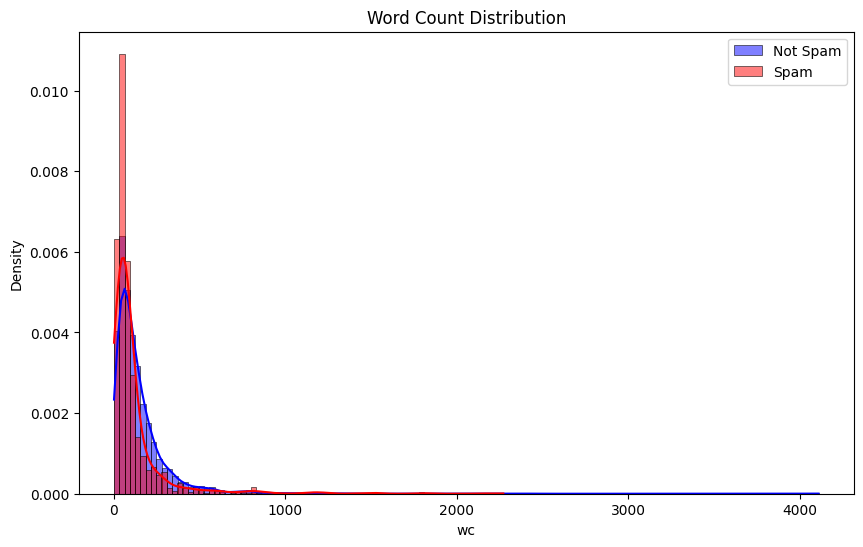

In [109]:
plt.figure(figsize=(10, 6))
# Plotting Not Spam lengths
sns.histplot(df[df['spam'] == 0]['wc'], color='blue', label='Not Spam', kde=True, stat="density")
# Plotting Spam lengths
sns.histplot(df[df['spam'] == 1]['wc'], color='red', label='Spam', kde=True, stat="density")

plt.title('Word Count Distribution')
plt.legend()
plt.show()

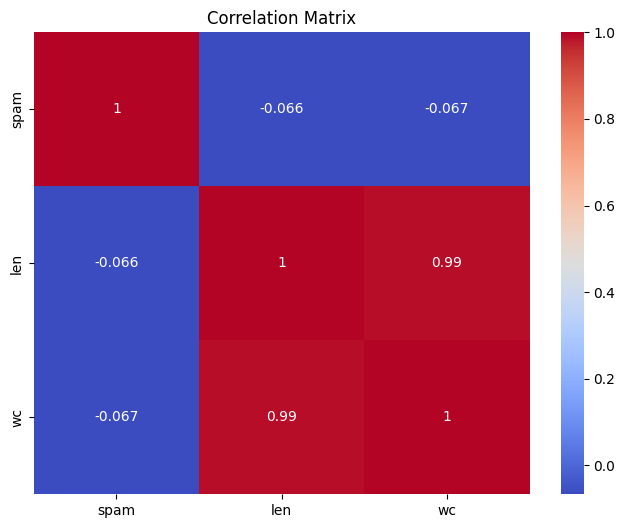

In [110]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['spam', 'len', 'wc']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


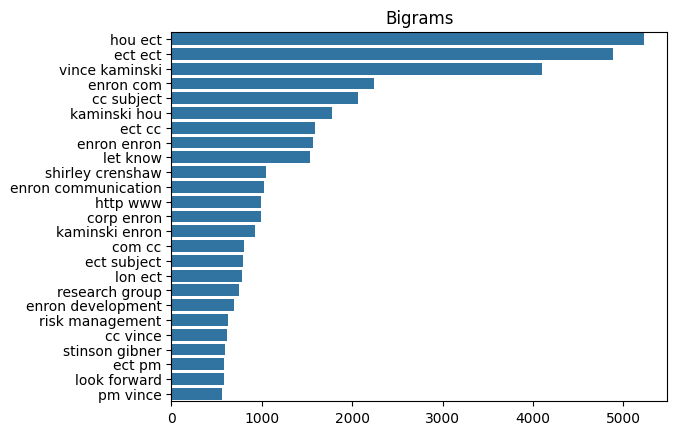

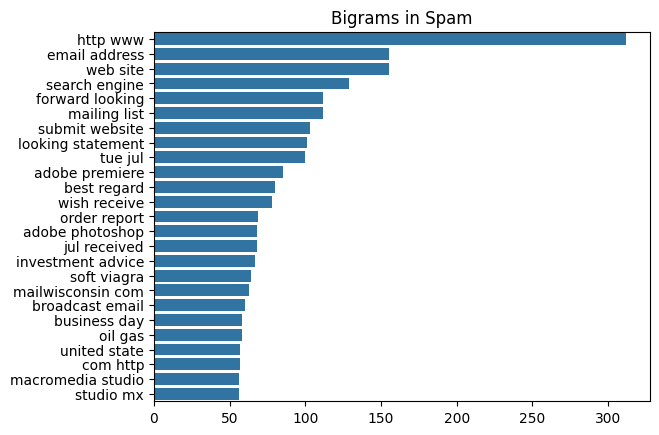

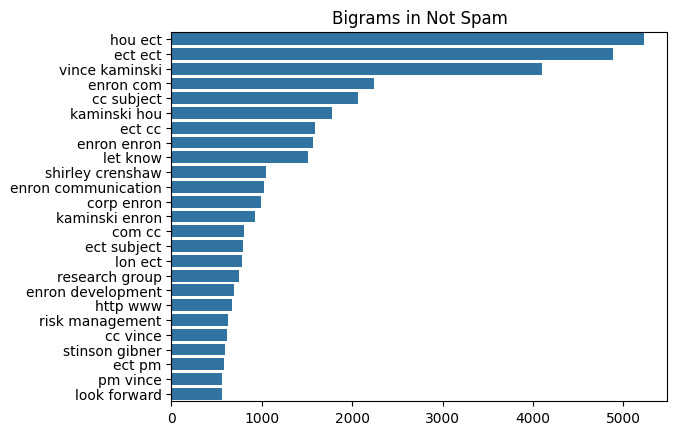

In [111]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
def draw_ngram(only_the_data, TITLE):
    def get_top_ngrams(corpus, n=None):
        vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
        bag_of_words = vec.transform(corpus)
        sum_words = bag_of_words.sum(axis=0) 
        words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
        words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
        return words_freq[:25]

    top_bigrams = get_top_ngrams(only_the_data)
    x, y = map(list, zip(*top_bigrams))
    sns.barplot(x=y, y=x)
    plt.title(TITLE)
    plt.show()

draw_ngram(df['text'], "Bigrams")
draw_ngram(df[df['spam']==1]['text'], "Bigrams in Spam")
draw_ngram(df[df['spam']==0]['text'], "Bigrams in Not Spam")